# Analysing DSN states of trained DSGNN 

In [1]:
import os
import sys
import torch
import numpy as np
from pathlib import Path

# Add project root to path
sys.path.append(os.path.abspath('../'))

# Import project modules
from src.models.dsgnn import DeepStateGNN
from src.utils.dataloader import load_dataset, get_dataset_info
from src.utils.args import get_public_config
from src.utils.logging import get_logger

In [2]:
# Configuration
class Args:
    dataset = 'SD'
    years = '2019'
    seq_len = 12
    horizon = 12
    input_dim = 38
    bs = 64
    seed = 2023
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    use_metadata = True
    mask_name = 'point_missing_075'
    mask_iter = 4
    n_rand_dim = 64 
    n_context = 32
    n_hid = 128
    dropout = 0.3

args = Args()
print(f"Using device: {args.device}")
print(f"Dataset: {args.dataset}, Years: {args.years}")

Using device: cuda
Dataset: SD, Years: 2019


In [3]:
# Load dataset
data_path, adj_path, node_num = get_dataset_info(args.dataset)
print(f"Data path: {data_path}")
print(f"Adjacency path: {adj_path}")
print(f"Number of nodes: {node_num}")

# Create a simple logger
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
handler = logging.StreamHandler()
handler.setFormatter(logging.Formatter('%(message)s'))
logger.addHandler(handler)

# new_path = data_path.split('/')
# new_path.insert(-2, '..')
# new_path = '/'.join(new_path)
# print(new_path)
# new_path = '/home/hajisafi/projects/deep_state_gnn/LargeST/data/sd/'

# Load the data
dataloader, scaler = load_dataset(data_path, args, logger)

print(f"\nDataloaders created:")
print(f"  Train batches: {dataloader['train_loader'].num_batch}")
print(f"  Val batches: {dataloader['val_loader'].num_batch}")
print(f"  Test batches: {dataloader['test_loader'].num_batch}")

Data path: /home/hajisafi/projects/deep_state_gnn/LargeST/data/sd
Adjacency path: /home/hajisafi/projects/deep_state_gnn/LargeST/data/sd/sd_rn_adj.npy
Number of nodes: 716


Data shape: (35040, 716, 3)
/home/hajisafi/projects/deep_state_gnn/LargeST/src/utils/dataloader.py:188: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  input_mask = torch.load


Dataloaders created:
  Train batches: 328
  Val batches: 109
  Test batches: 109


In [4]:
# Initialize DSGNN model with typical hyperparameters
model = DeepStateGNN(
        **{
                "num_nodes": node_num,
                "seq_num": args.seq_len, 
                "in_dim": args.input_dim,
                "out_dim": args.horizon,
                "random_feature_dim": args.n_rand_dim,
                "node_emb_dim": args.n_context,
                "time_emb_dim": 32,
                "use_residual": True,
                "use_bn": True,
                "use_spatial": False,
                "hid_dim": args.n_hid,
                "n_contexts": args.n_context,
                "dropout": args.dropout,
                "time_of_day_size": 96, 
                "day_of_week_size": 7}
                    )

model = model.to(args.device)
print(f"Model initialized with {sum(p.numel() for p in model.parameters())} parameters")

Model initialized with 413680 parameters


In [5]:
checkpoint_path = '/home/hajisafi/projects/deep_state_gnn/LargeST/results/SD/DSGNN/12-03_21-43-55_6fa735/final_model_s2023.pt'

state_dict = torch.load(checkpoint_path, map_location=args.device)
model.load_state_dict(state_dict)
model.eval()

print("Checkpoint loaded successfully!")

Checkpoint loaded successfully!


/tmp/ipykernel_3878468/1558105493.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location=args.device)


In [6]:
# Get a sample batch from test set
test_iterator = dataloader['test_loader'].get_iterator()
X_sample, y_sample, x_mask_sample, y_mask_sample = next(test_iterator)

# Convert to tensors
X_sample = torch.tensor(X_sample, dtype=torch.float32).to(args.device)
y_sample = torch.tensor(y_sample, dtype=torch.float32).to(args.device)

print(f"Sample batch shapes:")
print(f"  X: {X_sample.shape} (batch, time, nodes, features)")
print(f"  y: {y_sample.shape} (batch, horizon, nodes, 1)")
print(f"  x_mask: {x_mask_sample.shape}")
print(f"  y_mask: {y_mask_sample.shape}")

Sample batch shapes:
  X: torch.Size([64, 12, 716, 38]) (batch, time, nodes, features)
  y: torch.Size([64, 12, 716, 1]) (batch, horizon, nodes, 1)
  x_mask: (64, 12, 716, 1)
  y_mask: (64, 12, 716, 1)


In [7]:
# Run inference to get predictions and internal states
with torch.no_grad():
    output_dict = model(X_sample.transpose(1, 2), y_sample)
    
    predictions = output_dict['prediction']
    assignment_scores_source = output_dict['assignment_scores_source']
    assignment_scores_target = output_dict['assignment_scores_target']

print(f"\nModel outputs:")
print(f"  Predictions: {predictions.shape}")
print(f"  Assignment scores (obs->DSN): {assignment_scores_source.shape}")
print(f"  Assignment scores (DSN->obs): {assignment_scores_target.shape}")
print(f"\nModel successfully loaded and ready for analysis.")

/home/hajisafi/projects/deep_state_gnn/LargeST/src/models/dsgnn.py:40: UserWarning: torch.qr is deprecated in favor of torch.linalg.qr and will be removed in a future PyTorch release.
The boolean parameter 'some' has been replaced with a string parameter 'mode'.
Q, R = torch.qr(A, some)
should be replaced with
Q, R = torch.linalg.qr(A, 'reduced' if some else 'complete') (Triggered internally at /opt/conda/conda-bld/pytorch_1724789220573/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:2416.)
  q, _ = torch.qr(unstructured_block)



Model outputs:
  Predictions: torch.Size([64, 12, 716, 1])
  Assignment scores (obs->DSN): torch.Size([64, 32, 1, 1])
  Assignment scores (DSN->obs): torch.Size([64, 716, 1, 1])

Model successfully loaded and ready for analysis.


In [8]:
# analyze the similarity of DSN states, visualize heatmap for cosine similarity
output_dict.keys()

dict_keys(['prediction', 'assignment_scores_source', 'assignment_scores_target', 'dsn_states'])

In [12]:
output_dict['dsn_states'].keys()

dict_keys(['raw', 'obs_augmented', 'gnn_convolved'])

In [16]:
raw_dsn = output_dict['dsn_states']['raw']
obs_augmented_dsn = output_dict['dsn_states']['obs_augmented']
gnn_convolved_dsn = output_dict['dsn_states']['gnn_convolved']

# print shapes
print(f"Raw DSN shape: {raw_dsn.shape}")
print(f"Obs-augmented DSN shape: {obs_augmented_dsn.shape}")
print(f"GNN-convolved DSN shape: {gnn_convolved_dsn.shape}")

Raw DSN shape: torch.Size([64, 32, 32])
Obs-augmented DSN shape: torch.Size([64, 32, 128])
GNN-convolved DSN shape: torch.Size([64, 32, 320])


Text(0.5, 1.0, 'Cosine Similarity Heatmap of GNN-Convolved DSN States (First Batch Item)')

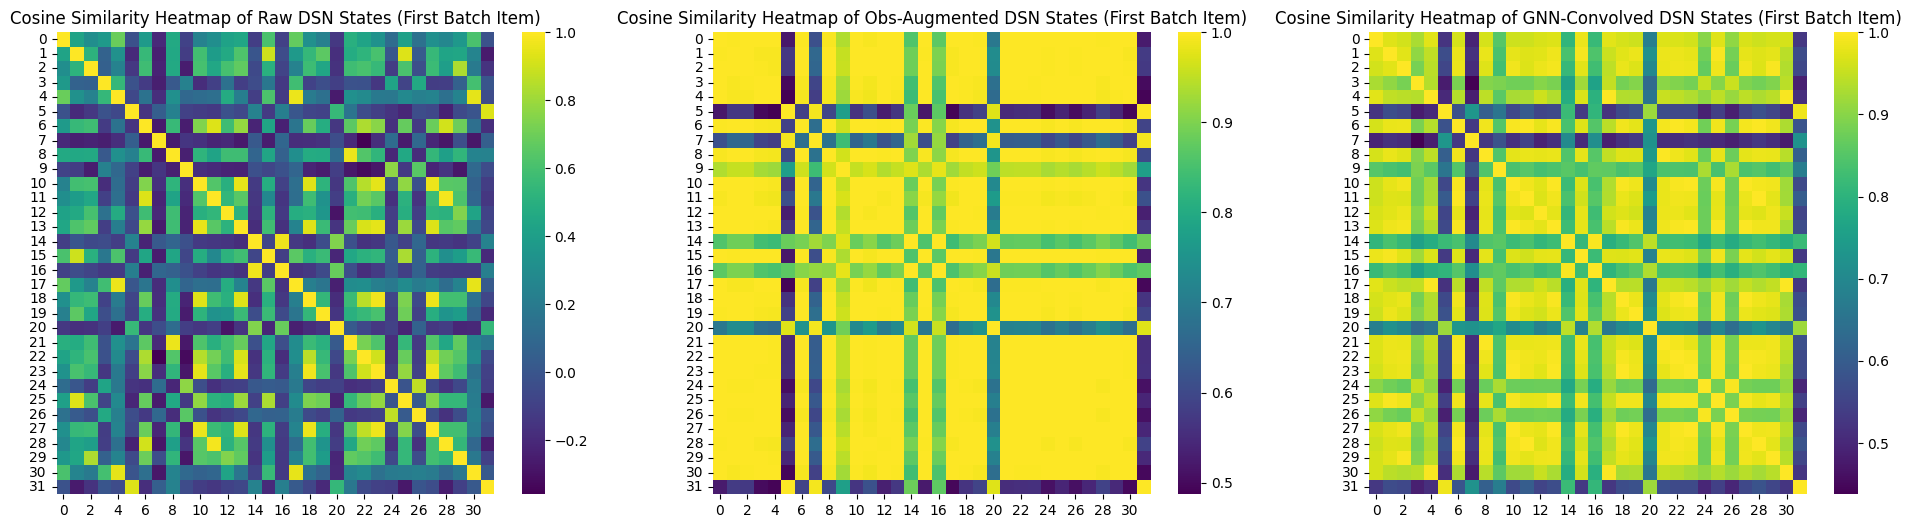

In [22]:
# visualize heatmap of dsn state cosine sim for first item in batch
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

cos_sim_matrix_raw = cosine_similarity(raw_dsn[0].detach().cpu().numpy())  # (C, C)
cos_sim_matrix_obs_aug = cosine_similarity(obs_augmented_dsn[0].detach().cpu().numpy())  # (C, C)
cos_sim_matrix_gnn_conv = cosine_similarity(gnn_convolved_dsn[0].detach().cpu().numpy())  # (C, C)
plt.subplots(1, 3, figsize=(24, 6))
plt.subplot(1, 3, 1)
sns.heatmap(cos_sim_matrix_raw, cmap='viridis')
plt.title('Cosine Similarity Heatmap of Raw DSN States (First Batch Item)')
plt.subplot(1, 3, 2)
sns.heatmap(cos_sim_matrix_obs_aug, cmap='viridis')
plt.title('Cosine Similarity Heatmap of Obs-Augmented DSN States (First Batch Item)')
plt.subplot(1, 3, 3)
sns.heatmap(cos_sim_matrix_gnn_conv, cmap='viridis')
plt.title('Cosine Similarity Heatmap of GNN-Convolved DSN States (First Batch Item)')